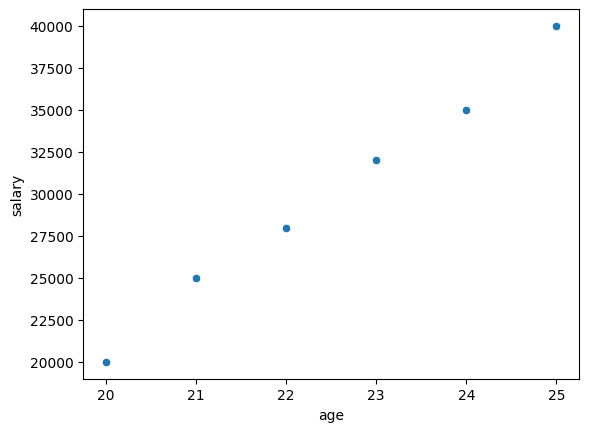

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data = {
    "age": [20, 21, 22, 23, 24, 25],
    "salary": [20000, 25000, 28000, 32000, 35000, 40000]
}

df = pd.DataFrame(data)
sns.scatterplot(data=df, x="age", y="salary")
sns.get_dataset_names()

plt.show()

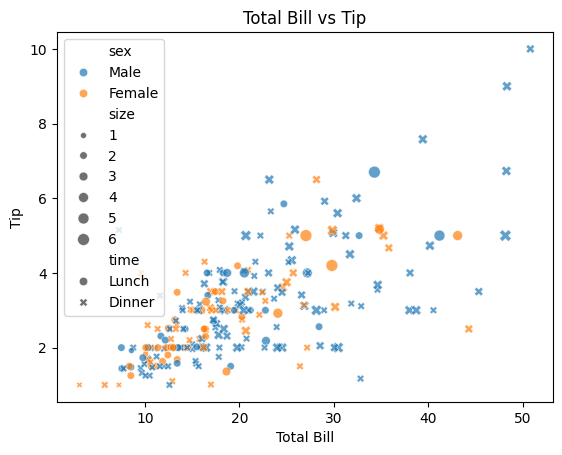

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips.head()

sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    style="time",
    size="size",
    alpha=0.7
)

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()




In [8]:
tips.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


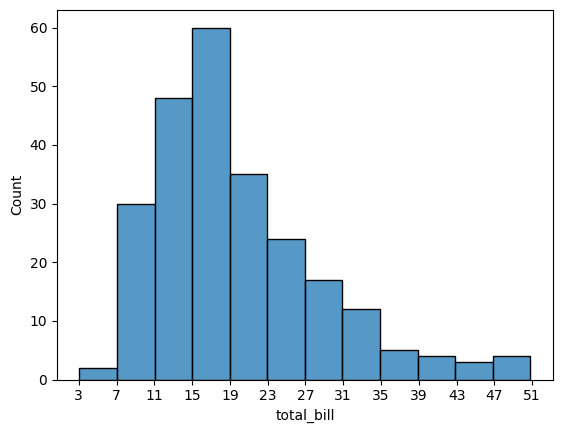

In [19]:
sns.histplot(data=tips, x="total_bill",bins=12)
plt.xticks([3,7,11,15,19,23,27,31,35,39,43,47,51])
plt.show()

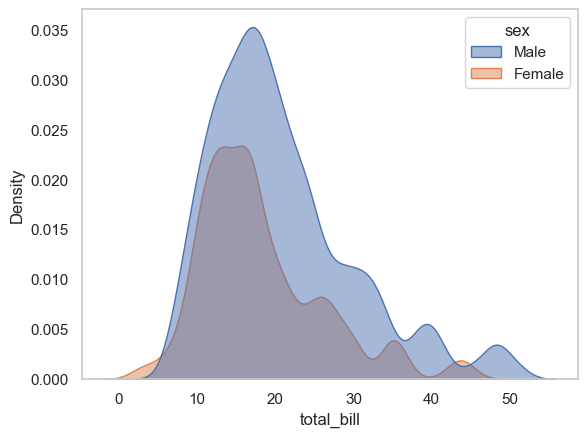

In [29]:
sns.set_theme(style="whitegrid")
sns.kdeplot(
    data=tips,
    x="total_bill",
    hue="sex",
    fill=True,
    alpha=0.5,
    bw_adjust=0.5
)
plt.grid()

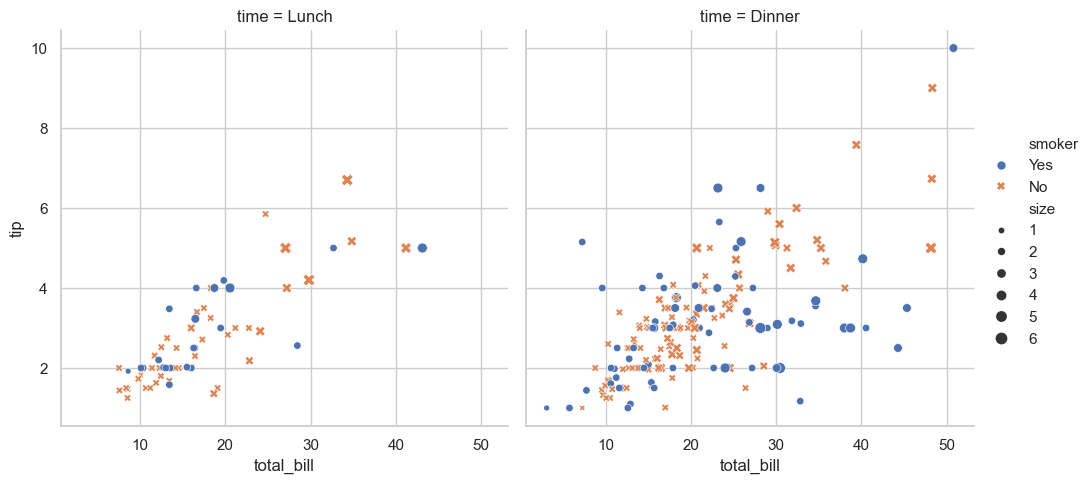

In [27]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

<Axes: xlabel='day', ylabel='total_bill'>

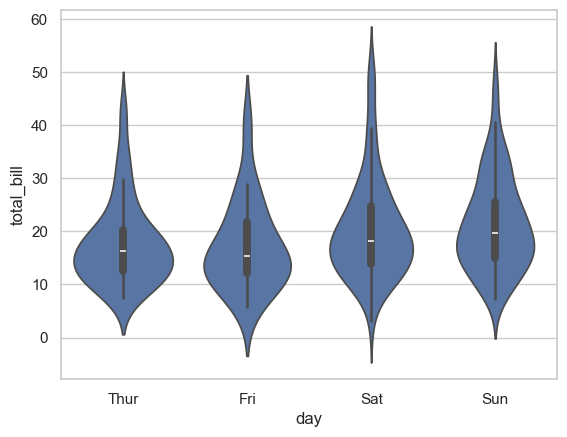

In [30]:
sns.violinplot(
    data=tips,
    x="day",
    y="total_bill"
)

<Axes: xlabel='day', ylabel='total_bill'>

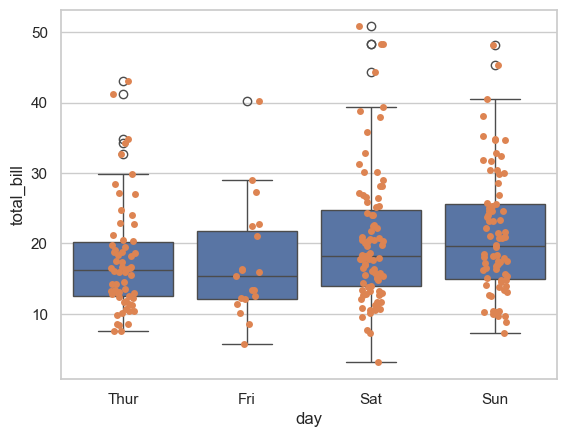

In [31]:
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill"
)

sns.stripplot(
    data=tips,
    x="day",
    y="total_bill"
)

<Axes: xlabel='total_bill', ylabel='tip'>

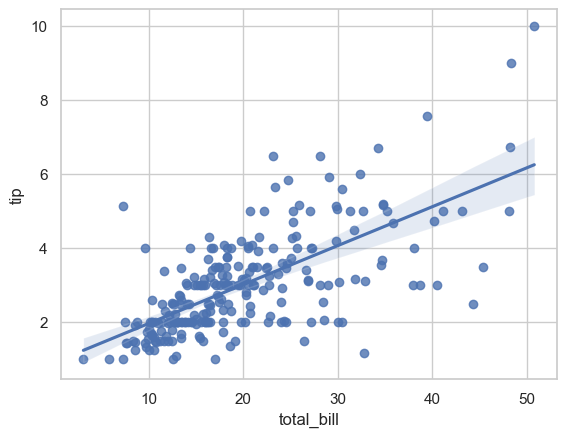

In [32]:
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip"
)

[[ True  True  True]
 [False  True  True]
 [False False  True]]


<Axes: >

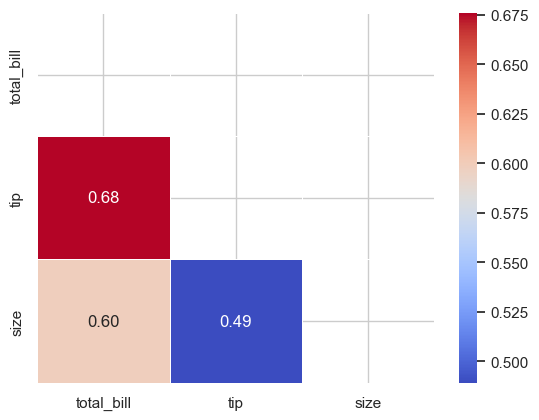

In [44]:
import numpy as np
df = sns.load_dataset('tips')
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
print(mask)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    mask=mask,
)

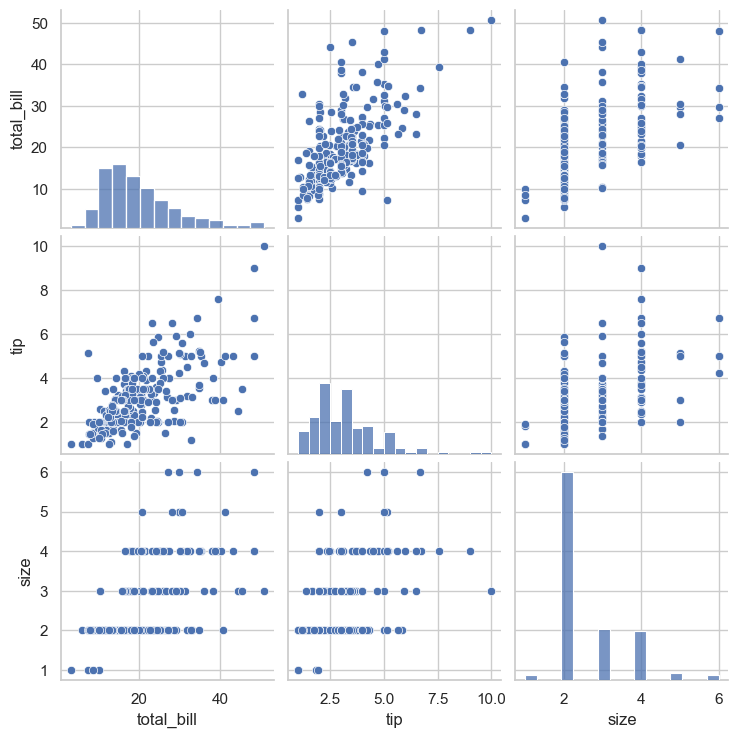

In [49]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.pairplot(df)
plt.show()

<Axes: xlabel='day', ylabel='total_bill'>

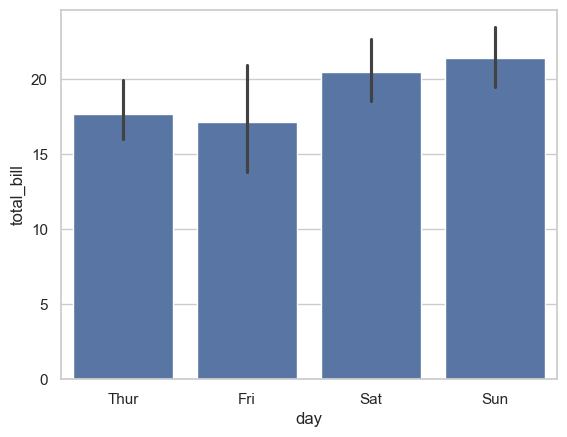

In [50]:
sns.barplot(
    data=tips,
    x="day",
    y="total_bill",
    estimator="mean"
)

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = sns.load_dataset("tips")
print(df.head())

X = df[["total_bill", "tip", "size"]]
y = df["smoker"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_test, y_pred))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Accuracy: 0.6530612244897959
Confusion Matrix:
[[29  2]
 [15  3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.94      0.77        31
           1       0.60      0.17      0.26        18

    accuracy                           0.65        49
   macro avg       0.63      0.55      0.52        49
weighted avg       0.64      0.65      0.59        49



In [5]:
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = sns.load_dataset("tips")
print(df.head())

X = df[["total_bill", "smoker", "size"]]
y = df["tip"]

X = X.copy()
X["smoker"] = X["smoker"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
R² Score: 0.4507089585036145
Mean Squared Error: 0.6865980620855362
